In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import time
import anndata as an
import scanpy as sc
import scanpy.external as sce
import h5py
import scipy
from scipy.stats import pearsonr
from scipy import stats
from scipy.spatial.distance import cdist
from statsmodels.stats.multitest import multipletests
from tqdm import tqdm
import re
import matplotlib.colors as mcolors
import networkx as nx
from itertools import combinations
import json
import random
from adjustText import adjust_text

sc.settings.verbosity = 2

* Pearson r on log-normalized expression data (inflated type-I errors)
* Spearman r on log-normalized expression data (inflated type-I errors)
* 

In [2]:
%%time
path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_all_groups_v2.h5ad"
adata = sc.read_h5ad(path)
sc.logging.print_memory_usage()
adata

Memory usage: current 2.41 GB, difference +2.41 GB
CPU times: user 628 ms, sys: 1.73 s, total: 2.36 s
Wall time: 8.25 s


/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/anndata/logging.py:57: FutureWarning: The specified parameters ('newline',) are no longer positional. Please specify them like `newline=False`
  print(format_memory_usage(get_memory_usage(), msg, newline))


AnnData object with n_obs × n_vars = 16296 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'st

In [9]:
tdata = adata[adata.obs['pooled_condition'] == 'Control', :].copy()

sc.pp.highly_variable_genes(
    tdata,
    flavor='seurat_v3',
    layer='raw_counts',
    n_top_genes=500,
)

print(tdata.var['highly_variable'].sum())

tdata = tdata[:, tdata.var['highly_variable']].copy()
tdata

extracting highly variable genes
500


AnnData object with n_obs × n_vars = 6902 × 500
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'std',

In [12]:
tdata.X = tdata.layers['log_norm'].copy()

X = tdata.X if isinstance(tdata.X, np.ndarray) else tdata.X.toarray()

pairs = []
for i, j in combinations(range(X.shape[1]), 2):
    r, p = pearsonr(X[:, i], X[:, j])
    pairs.append((i, j, r, p))


df = pd.DataFrame(pairs, columns=["gene_i", "gene_j", "r", "p"])
print(df.shape)
df.head()

(124750, 4)


,gene_i,gene_j,r,p
0,0,1,-0.005625,6.403458e-01
1,0,2,-0.059763,6.746402e-07
2,0,3,-0.009082,4.506017e-01
3,0,4,-0.039205,1.122905e-03
4,0,5,-0.096305,1.074482e-15


In [10]:
tdata.X = tdata.layers['log_norm'].copy()

corr_method = 'pearson'

X = tdata.X if isinstance(tdata.X, np.ndarray) else tdata.X.toarray()

X_df = pd.DataFrame(
    X,
    index=tdata.obs_names,
    columns=tdata.var_names,
)

R = X_df.corr(method=corr_method) # genes x genes
print(R.shape)

# # p-values
# n

(500, 500)


Frac(p<0.05): 0.04868937875751503
KS test vs Uniform: KstestResult(statistic=np.float64(0.01222867704398084), pvalue=np.float64(1.2396350715906882e-16), statistic_location=np.float64(0.3817677552002935), statistic_sign=np.int8(-1))


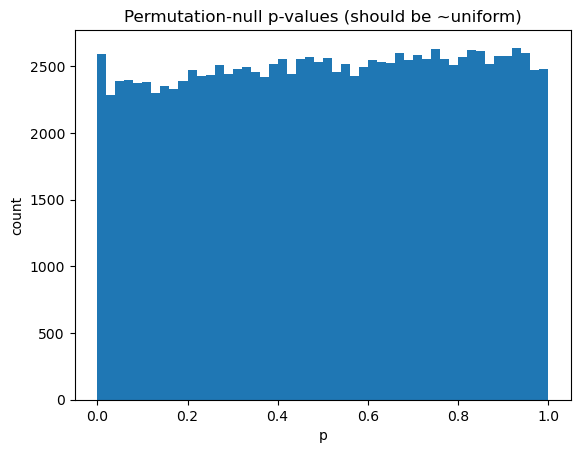

In [11]:
X = X_df.values
n, g = X.shape
iu = np.triu_indices(g, k=1)

def null_pvals(seed=0):
    rng = np.random.default_rng(seed)
    Xnull = X.copy()
    for j in range(g):
        rng.shuffle(Xnull[:, j])     # breaks all gene–gene correlation
    R = np.corrcoef(Xnull, rowvar=False)
    df = n - 2
    r = np.clip(R, -0.999999999999, 0.999999999999)
    t = r * np.sqrt(df / (1 - r**2))
    P = 2 * stats.t.sf(np.abs(t), df)
    return P[iu]

pvec = null_pvals(seed=0)
pvec = pvec[np.isfinite(pvec)]

print("Frac(p<0.05):", np.mean(pvec < 0.05))
print("KS test vs Uniform:", stats.kstest(pvec, "uniform"))

plt.hist(pvec, bins=50, range=(0,1))
plt.title("Permutation-null p-values (should be ~uniform)")
plt.xlabel("p"); plt.ylabel("count")
plt.show()